
# Nonstationary 10-Armed Bandit — Sample-Average vs Constant Step-Size

This notebook reproduces the experiment described in Sutton & Barto (2nd Ed.), Chapter 2:

> *Design and conduct an experiment to demonstrate the difficulties that sample-average methods have for nonstationary problems.*

**Setup**  
- 10 arms; all true values start at 0.  
- On each step, each arm's true value `q*(a)` follows an **independent random walk**: add Normal(0, 0.01).  
- Rewards are Normal(q\*(a), 1).  
- Action selection: **ε-greedy** with ε = 0.1 (ties broken by argmax).  
- Compare two update rules:  
  1. **Sample-average**: αₙ = 1 / Nₐ (shrinks over time)  
  2. **Constant step size**: α = 0.1 (fixed, good for drift)

We plot (like Fig. 2.2):  
- Average reward vs steps  
- % optimal action vs steps

> Tip: You can increase `runs` to get smoother curves, at the cost of runtime.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Use default matplotlib styling (no seaborn)
%matplotlib inline


## Parameters

In [2]:

# Experiment parameters
k = 10                 # number of arms
runs = 500             # number of independent runs (increase to 2000 for smoother curves)
steps = 10000          # steps per run
epsilon = 0.1          # epsilon-greedy exploration rate
alpha_const = 0.1      # constant step size for the constant-alpha method
random_walk_std = 0.01 # std for random walk increments of q*
reward_std = 1.0       # reward noise std

seed = 123             # base seed for reproducibility (set to None for fresh randomness)


## Helper functions

In [3]:

def eps_greedy(Q, eps, rng):
    """ε-greedy action selection with simple argmax tie-break."""
    if rng.random() < eps:
        return int(rng.integers(0, Q.size))
    return int(np.argmax(Q))

def run_single(rng, k, steps, epsilon, alpha_const, random_walk_std, reward_std):
    """Run one trajectory for both agents on the same drifting q* sequence."""
    q_star = np.zeros(k, dtype=float)      # true values, start equal
    Q_sa = np.zeros(k, dtype=float)        # sample-average estimates
    N_sa = np.zeros(k, dtype=int)          # counts per action
    Q_const = np.zeros(k, dtype=float)     # constant-alpha estimates

    rewards_sa = np.zeros(steps, dtype=float)
    rewards_const = np.zeros(steps, dtype=float)
    opt_sa = np.zeros(steps, dtype=bool)
    opt_const = np.zeros(steps, dtype=bool)

    for t in range(steps):
        opt_a = int(np.argmax(q_star))

        # --- Sample-average agent ---
        a1 = eps_greedy(Q_sa, epsilon, rng)
        r1 = rng.normal(q_star[a1], reward_std)
        rewards_sa[t] = r1
        opt_sa[t] = (a1 == opt_a)
        N_sa[a1] += 1
        alpha_sa = 1.0 / N_sa[a1]
        Q_sa[a1] += alpha_sa * (r1 - Q_sa[a1])

        # --- Constant-alpha agent ---
        a2 = eps_greedy(Q_const, epsilon, rng)
        r2 = rng.normal(q_star[a2], reward_std)
        rewards_const[t] = r2
        opt_const[t] = (a2 == opt_a)
        Q_const[a2] += alpha_const * (r2 - Q_const[a2])

        # Random walk of q*
        q_star += rng.normal(0.0, random_walk_std, size=k)

    return rewards_sa, rewards_const, opt_sa, opt_const


## Run experiment

In [4]:

base_rng = np.random.default_rng(seed)

avg_reward_sa = np.zeros(steps, dtype=float)
avg_reward_const = np.zeros(steps, dtype=float)
pct_opt_sa = np.zeros(steps, dtype=float)
pct_opt_const = np.zeros(steps, dtype=float)

for _ in range(runs):
    rng = np.random.default_rng(base_rng.integers(0, 2**32 - 1))
    r_sa, r_const, o_sa, o_const = run_single(
        rng, k, steps, epsilon, alpha_const, random_walk_std, reward_std
    )
    avg_reward_sa += r_sa
    avg_reward_const += r_const
    pct_opt_sa += o_sa.astype(float)
    pct_opt_const += o_const.astype(float)

avg_reward_sa /= runs
avg_reward_const /= runs
pct_opt_sa = (pct_opt_sa / runs) * 100.0
pct_opt_const = (pct_opt_const / runs) * 100.0


## Plots

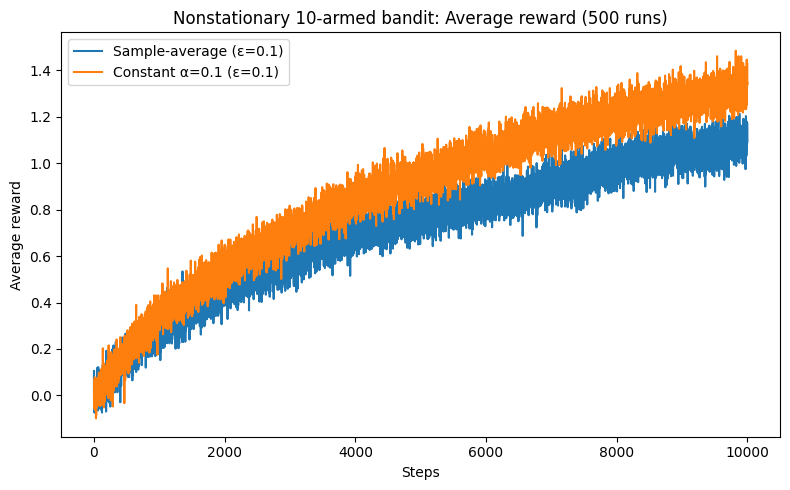

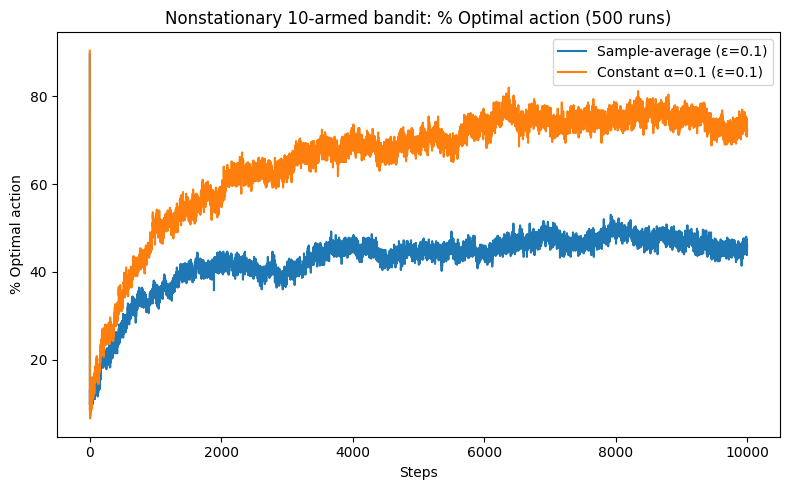

In [5]:

plt.figure(figsize=(8,5))
plt.plot(avg_reward_sa, label="Sample-average (ε=0.1)")
plt.plot(avg_reward_const, label="Constant α=0.1 (ε=0.1)")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title(f"Nonstationary 10-armed bandit: Average reward ({runs} runs)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(pct_opt_sa, label="Sample-average (ε=0.1)")
plt.plot(pct_opt_const, label="Constant α=0.1 (ε=0.1)")
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title(f"Nonstationary 10-armed bandit: % Optimal action ({runs} runs)")
plt.legend()
plt.tight_layout()
plt.show()



### Notes
- **Why constant α wins here:** sample-average's effective step size shrinks as `1/Nₐ`, so it becomes sluggish in tracking drifting optima. A constant α forgets the distant past and stays responsive to recent rewards—crucial in nonstationary settings.
- Try different `alpha_const` (e.g., 0.05 vs 0.2) to see the stability–adaptation trade-off.
- Increase `runs` to 2000 for smoother curves (expect longer runtime).
